## Integrantes

Raful Habib Sánchez Morales — A01127380  
Efrén Alejandro Barroso Llanes — A01795861  
Michelle Alicia Graver Aguilar — A01242013


# Avance 3. Baseline (Modelo de Referencia)




## Índice — Baseline

18. **Justificación del Algoritmo Baseline**  
    - 18.1 Análisis del Tipo de Problema  
    - 18.2 Selección del Algoritmo: Regresión Logística  

19. **Preparación de Datos para Modelado**  
    - 19.1 Construcción de Matrices X e y  
    - 19.2 División Estratificada Entrenamiento / Prueba  
    - 19.3 Balance de Clases en Cada Partición  

20. **Modelo de Referencia Aleatorio — `DummyClassifier`**  

21. **Baseline — Comparación de 3 Estrategias de Feature Engineering**  
    - 21.1 Preparación de los 3 Datasets (**FULL**, **CLUSTERING**, **FILTER**)  
    - 21.2 Entrenamiento con Regresión Logística + SMOTE  
    - 21.3 Comparación y Diagnóstico (4 Casos):  
      * **CASO 1:** FILTER ≈ CLUSTERING ≈ FULL → Pocas variables son suficientes  
      * **CASO 2:** CLUSTERING ≈ FULL, FILTER peor → Variables redundantes aportan  
      * **CASO 3:** FILTER ≈ FULL, CLUSTERING peor → Se perdió información en clustering  
      * **CASO 4:** FULL mejor que todos → Se requiere toda la información disponible  

22. **Análisis de Características Importantes**  
    - 22.1 Coeficientes del Modelo — Métodos Filter + Modelo  
    - 22.2 Visualización de las Características Más Relevantes  

23. **Métricas de Evaluación**  
    - 23.1 Justificación de Métricas para Clases Desbalanceadas  
    - 23.2 Reporte de Clasificación  
    - 23.3 Matriz de Confusión  
    - 23.4 Curva ROC-AUC y Curva Precisión-Recall  

24. **Análisis de Sub/Sobreajuste**  
    - 24.1 Comparación de Métricas Entrenamiento vs Prueba  
    - 24.2 Curvas de Aprendizaje  
    - 24.3 Validación Cruzada Estratificada (5-Fold)  

25. **Desempeño Mínimo Aceptable**  
    - 25.1 Definición del Umbral de Desempeño  
    - 25.2 Comparación con el Umbral Aceptable  
    - 25.3 Verificación del Modelo Baseline  

26. **Conclusiones — Fase de Modelado Baseline (CRISP-ML)**  
    - 26.1 Respuestas a las Preguntas Guía  
    - 26.2 Tabla Resumen de Resultados  
    - 26.3 Siguientes Pasos (CRISP-ML)  
    - 26.4 Referencias


In [ ]:
# ── Importaciones adicionales para la sección Baseline ──────────────
from sklearn.dummy          import DummyClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, learning_curve)
from sklearn.metrics        import (classification_report, confusion_matrix,
                                    ConfusionMatrixDisplay,
                                    roc_auc_score, roc_curve,
                                    balanced_accuracy_score, f1_score,
                                    precision_score, recall_score,
                                    average_precision_score,
                                    PrecisionRecallDisplay)
from sklearn.pipeline       import Pipeline
import warnings
warnings.filterwarnings('ignore')

print('Librerías de modelado cargadas correctamente.')

Librerías de modelado cargadas correctamente.


---
## 18. Justificación del Algoritmo Baseline

### 18.1 Análisis del Tipo de Problema

| Dimensión | Característica del problema |
|---|---|
| **Tipo de datos** | Estructurados — tabla con variables de expresión génica (numéricas) y clínicas (categóricas) |
| **Tipo de tarea** | Clasificación binaria supervisada: Psoriasis (`1`) vs. Control sano (`0`) |
| **Tamaño del dataset** | Pocas muestras (docenas/centenas de pacientes), muchas características (cientos de sondas genómicas) → régimen *p >> n* |
| **Balance de clases** | Potencialmente desbalanceado (evaluado en sección 19) |
| **Interpretabilidad** | Alta: importa saber qué genes/variables clínicas discriminan la condición |
| **Línea base de referencia** | Clasificador aleatorio estratificado (DummyClassifier) |

### 18.2 Selección del Algoritmo: Regresión Logística

**Justificación frente a las alternativas:**

| Algoritmo | Pros | Contras para este caso |
|---|---|---|
| **Regresión Logística** ✅ | Simple, interpretable, coeficientes = importancia, funciona bien con regularización en *p >> n* | Asume linealidad; requiere escalado |
| Árbol de Decisión | Interpretable, no requiere escalado | Propenso a sobreajuste; no es un buen *baseline* |
| KNN | No paramétrico | Muy sensible a la dimensionalidad (*curse of dimensionality*) |
| SVM lineal | Bueno en *p >> n* | Menos interpretable; coeficientes no son probabilidades |
| Red neuronal | Alta capacidad | Requiere muchos datos; no apropiada como baseline |

La **Regresión Logística con regularización L2** (Ridge) es el baseline estándar para clasificación binaria con datos estructurados de alta dimensionalidad. Permite:
- Obtener probabilidades calibradas.
- Interpretar los coeficientes como importancia de características.
- Controlar el sobreajuste mediante el parámetro `C`.
- Manejar clases desbalanceadas con `class_weight='balanced'`.

---
## 19. Preparación de Datos para Modelado

### 19.1 Construcción de Matrices X e y

In [ ]:
# Las matrices X_todas, X_reducida_pca, X_reducida_fa y y fueron construidas en la sección FE.
# Verificamos que estén disponibles y reseteamos índices para consistencia.

assert 'X_todas'        in dir() or 'X_todas'        in locals(), 'Ejecutar primero la sección FE (Sección 14)'
assert 'X_reducida_pca' in dir() or 'X_reducida_pca' in locals(), 'Ejecutar primero la sección FE (Sección 15)'
assert 'y'              in dir() or 'y'              in locals(), 'Ejecutar primero la sección FE (target y)'

# Reset de índices para alinear correctamente con sklearn
X_todas_bl        = X_todas.reset_index(drop=True)
X_pca_bl          = X_reducida_pca.reset_index(drop=True)
# Convert y to numerical labels (0 for 'Healthy', 1 for 'Psoriasis')
y_bl              = y.map({'Healthy': 0, 'Psoriasis': 1}).reset_index(drop=True)


print('=== Matrices disponibles para modelado ===')
print(f'  X_todas        : {X_todas_bl.shape}')
print(f'  X_reducida_pca : {X_pca_bl.shape}')
print(f'  y (target)     : {y_bl.shape}  — clases: {dict(y_bl.value_counts())}')

=== Matrices disponibles para modelado ===
  X_todas        : (599, 391)
  X_reducida_pca : (599, 77)
  y (target)     : (599,)  — clases: {1: np.int64(423), 0: np.int64(176)}


### 19.2 División Estratificada Entrenamiento / Prueba

Se utiliza `stratify=y` para mantener la proporción de clases en ambas particiones. Una división 80/20 es estándar para datasets de tamaño moderado.

In [ ]:
TEST_SIZE   = 0.20
RANDOM_SEED = 42

# División para X_todas
X_train_t, X_test_t, y_train, y_test = train_test_split(
    X_todas_bl, y_bl, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_bl
)

# División para X_pca (mismos índices → mismos registros)
X_train_p = X_pca_bl.loc[X_train_t.index]
X_test_p  = X_pca_bl.loc[X_test_t.index]

print(f'Tamaño de entrenamiento : {X_train_t.shape[0]} muestras')
print(f'Tamaño de prueba        : {X_test_t.shape[0]} muestras')
print(f'\nDistribución de clases en entrenamiento:')
print(y_train.value_counts())
print(f'\nDistribución de clases en prueba:')
print(y_test.value_counts())

Tamaño de entrenamiento : 479 muestras
Tamaño de prueba        : 120 muestras

Distribución de clases en entrenamiento:
Condition/control
1    338
0    141
Name: count, dtype: int64

Distribución de clases en prueba:
Condition/control
1    85
0    35
Name: count, dtype: int64


In [ ]:
# ── 19.2b Aplicación de SMOTE al conjunto de entrenamiento ──────────────────
# SMOTE se aplica ÚNICAMENTE sobre el conjunto de entrenamiento para evitar
# data leakage. El conjunto de prueba permanece con la distribución original.

ratio_raw = y_train.value_counts().max() / y_train.value_counts().min()
print(f'Ratio de desbalance ANTES de SMOTE: {ratio_raw:.2f}:1')
print(f'Clases en entrenamiento: {dict(y_train.value_counts())}')

smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)

# X_todas (datos completos escalados)
X_train_sm, y_train_sm = smote.fit_resample(X_train_t, y_train)

# X_pca (representación reducida)
X_train_p_sm, _ = smote.fit_resample(X_train_p, y_train)

print(f'\nDistribución DESPUÉS de SMOTE:')
print(f'  Clases: {dict(pd.Series(y_train_sm).value_counts())}')
print(f'  Muestras totales en entrenamiento: {X_train_sm.shape[0]}  '
      f'(antes: {X_train_t.shape[0]})')
print(f'\nNota: el conjunto de prueba NO se modifica ({X_test_t.shape[0]} muestras).')

Ratio de desbalance ANTES de SMOTE: 2.40:1
Clases en entrenamiento: {1: np.int64(338), 0: np.int64(141)}

Distribución DESPUÉS de SMOTE:
  Clases: {0: np.int64(338), 1: np.int64(338)}
  Muestras totales en entrenamiento: 676  (antes: 479)

Nota: el conjunto de prueba NO se modifica (120 muestras).


### 19.3 Balance de Clases en Cada Partición

Ratio de desbalance original      : 2.40:1
Ratio de desbalance post-SMOTE    : 1.00:1  (objetivo: 1.00:1)
→ SMOTE aplicado: clases balanceadas para el entrenamiento.


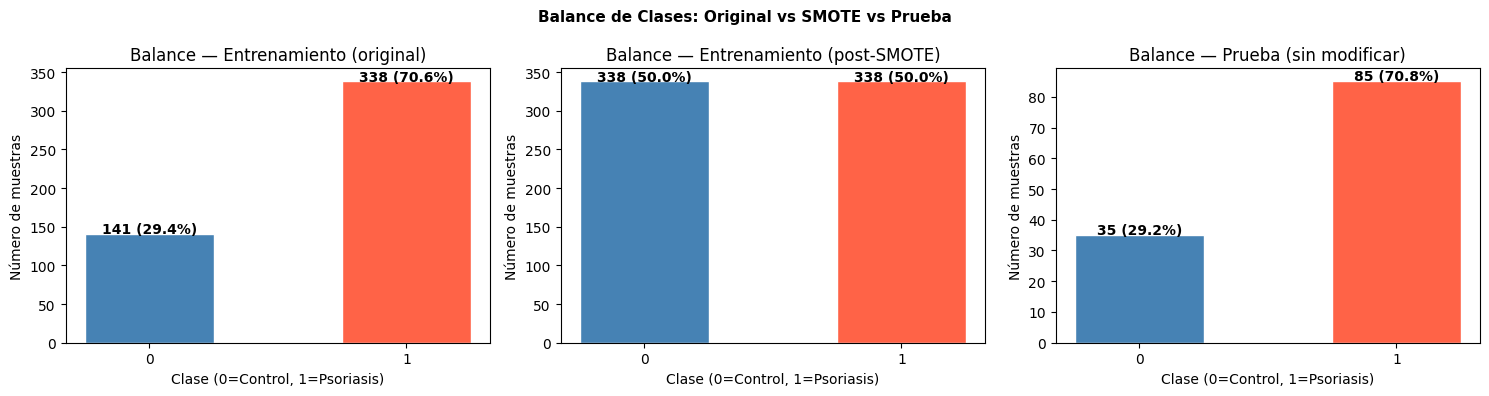

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, y_part) in zip(axes, [
    ('Entrenamiento (original)',    y_train),
    ('Entrenamiento (post-SMOTE)', pd.Series(y_train_sm)),
    ('Prueba (sin modificar)',     y_test),
]):
    conteo = pd.Series(y_part).value_counts().sort_index()
    colores_clase = ['steelblue' if c == 0 else 'tomato' for c in conteo.index]
    ax.bar([str(c) for c in conteo.index], conteo.values,
           color=colores_clase, edgecolor='white', width=0.5)
    for i, (v, p) in enumerate(zip(conteo.values, (conteo / conteo.sum() * 100).values)):
        ax.text(i, v + 0.5, f'{v} ({p:.1f}%)', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'Balance — {nombre}')
    ax.set_xlabel('Clase (0=Control, 1=Psoriasis)')
    ax.set_ylabel('Número de muestras')

ratio_train = y_train.value_counts().max() / y_train.value_counts().min()
ratio_sm    = pd.Series(y_train_sm).value_counts().max() / pd.Series(y_train_sm).value_counts().min()
print(f'Ratio de desbalance original      : {ratio_train:.2f}:1')
print(f'Ratio de desbalance post-SMOTE    : {ratio_sm:.2f}:1  (objetivo: 1.00:1)')
print(f'→ SMOTE aplicado: clases balanceadas para el entrenamiento.')

plt.suptitle('Balance de Clases: Original vs SMOTE vs Prueba', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 20. Modelo de Referencia Aleatorio — `DummyClassifier`

**Propósito:** El `DummyClassifier` con estrategia `stratified` genera predicciones respetando la distribución de clases del conjunto de entrenamiento, sin aprender ningún patrón. Representa el **piso mínimo absoluto** de desempeño: cualquier modelo real debe superarlo significativamente para considerarse útil.

In [ ]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
dummy.fit(X_train_t, y_train)

y_pred_dummy = dummy.predict(X_test_t)
y_prob_dummy = dummy.predict_proba(X_test_t)[:, 1]

auc_dummy       = roc_auc_score(y_test, y_prob_dummy)
f1_dummy        = f1_score(y_test, y_pred_dummy, average='weighted')
bal_acc_dummy   = balanced_accuracy_score(y_test, y_pred_dummy)

print('=== DummyClassifier (Referencia Aleatoria) ===')
print(f'  AUC-ROC           : {auc_dummy:.4f}')
print(f'  F1-score (weighted): {f1_dummy:.4f}')
print(f'  Balanced Accuracy  : {bal_acc_dummy:.4f}')
print('\n  → Estos valores representan el PISO MÍNIMO que debe superar el modelo baseline.')

=== DummyClassifier (Referencia Aleatoria) ===
  AUC-ROC           : 0.4639
  F1-score (weighted): 0.5536
  Balanced Accuracy  : 0.4639

  → Estos valores representan el PISO MÍNIMO que debe superar el modelo baseline.


## 21. Baseline — Comparación de 3 Estrategias de Feature Engineering

**Objetivo:** Comparar el desempeño de las 3 estrategias (FULL, CLUSTERING, FILTER) usando un modelo simple (Regresión Logística + SMOTE) para diagnosticar qué tipo de información es más valiosa.

**4 Casos Diagnósticos:**

- **CASO 1:** FILTER ≈ CLUSTERING ≈ FULL → Pocas variables son suficientes
- **CASO 2:** CLUSTERING ≈ FULL, FILTER peor → Variables redundantes aportan
- **CASO 3:** FILTER ≈ FULL, CLUSTERING peor → Se perdió información en clustering
- **CASO 4:** FULL mejor que todos → Se requiere toda la información disponible

### 21.1 Preparación de los 3 Datasets

In [ ]:
# Diccionario con los 3 datasets
datasets = {
    'FULL': X_FULL_completo,
    'CLUSTERING': X_CLUSTERING_completo,
    'FILTER': X_FILTER_completo
}

print('📊 DATASETS PARA BASELINE:')
for nombre, X in datasets.items():
    print(f'   {nombre:12s}: {X.shape}')

print(f'\n   Target: {y_temp.shape}')
print(f'   Distribución: {y_temp.value_counts().to_dict()}')

📊 DATASETS PARA BASELINE:
   FULL        : (599, 391)
   CLUSTERING  : (599, 145)
   FILTER      : (599, 71)

   Target: (599,)
   Distribución: {'Psoriasis': 423, 'Healthy': 176}


### 21.2 Entrenamiento con Regresión Logística + SMOTE

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score, roc_curve
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

resultados_baseline = {}

for nombre, X in datasets.items():
    print(f'\n🔧 Entrenando estrategia: {nombre}')

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_temp, test_size=0.2, random_state=42, stratify=y_temp
    )

    # SMOTE en train
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

    # Modelo
    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(X_train_bal, y_train_bal)

    # Predicciones
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    # Métricas
    auc = roc_auc_score(y_test, y_proba)
    bacc = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted') # FIX: Specify average='weighted' to handle string labels

    resultados_baseline[nombre] = {
        'AUC': auc,
        'Balanced_Acc': bacc,
        'F1': f1,
        'y_test': y_test,
        'y_proba': y_proba
    }

    print(f'   AUC: {auc:.3f} | Balanced Acc: {bacc:.3f} | F1: {f1:.3f}')


🔧 Entrenando estrategia: FULL
   AUC: 0.985 | Balanced Acc: 0.988 | F1: 0.983

🔧 Entrenando estrategia: CLUSTERING
   AUC: 0.976 | Balanced Acc: 0.976 | F1: 0.967

🔧 Entrenando estrategia: FILTER
   AUC: 0.997 | Balanced Acc: 0.982 | F1: 0.975


### 21.3 Comparación y Diagnóstico (4 Casos)


📊 RESULTADOS DEL BASELINE:
Estrategia      AUC  Balanced_Acc       F1
    FILTER 0.996639      0.982353 0.975289
      FULL 0.984874      0.988235 0.983466
CLUSTERING 0.976471      0.976471 0.967166


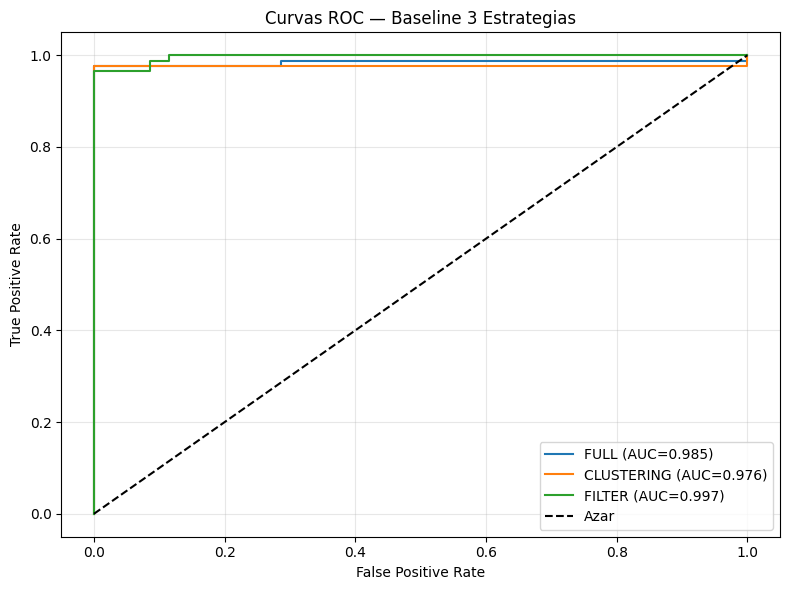


🔍 DIAGNÓSTICO:
   📊 Resultados no concluyentes, requiere análisis detallado


In [ ]:
# Tabla de resultados
df_resultados = pd.DataFrame({
    'Estrategia': list(resultados_baseline.keys()),
    'AUC': [r['AUC'] for r in resultados_baseline.values()],
    'Balanced_Acc': [r['Balanced_Acc'] for r in resultados_baseline.values()],
    'F1': [r['F1'] for r in resultados_baseline.values()]
}).sort_values('AUC', ascending=False)

print('\n📊 RESULTADOS DEL BASELINE:')
print(df_resultados.to_string(index=False))

# Curvas ROC
fig, ax = plt.subplots(figsize=(8, 6))

for nombre, res in resultados_baseline.items():
    fpr, tpr, _ = roc_curve(res['y_test'], res['y_proba'], pos_label='Psoriasis') # FIX: Explicitly set pos_label
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={res['AUC']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='Azar')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — Baseline 3 Estrategias')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# DIAGNÓSTICO AUTOMÁTICO
auc_full = resultados_baseline['FULL']['AUC']
auc_clust = resultados_baseline['CLUSTERING']['AUC']
auc_filt = resultados_baseline['FILTER']['AUC']

umbral_similar = 0.02  # Diferencia < 2% se considera similar

print('\n🔍 DIAGNÓSTICO:')

if abs(auc_filt - auc_clust) < umbral_similar and abs(auc_filt - auc_full) < umbral_similar:
    print('   ✅ CASO 1: FILTER ≈ CLUSTERING ≈ FULL')
    print('      → Pocas variables discriminativas son suficientes')
    print('      → Usar FILTER para reducir dimensionalidad sin pérdida')
elif abs(auc_clust - auc_full) < umbral_similar and auc_filt < auc_clust - umbral_similar:
    print('   ⚠️ CASO 2: CLUSTERING ≈ FULL, FILTER peor')
    print('      → Variables redundantes aportan información complementaria')
    print('      → Usar CLUSTERING como compromiso')
elif abs(auc_filt - auc_full) < umbral_similar and auc_clust < auc_full - umbral_similar:
    print('   ⚠️ CASO 3: FILTER ≈ FULL, CLUSTERING peor')
    print('      → Se perdió información valiosa en el clustering')
    print('      → Usar FILTER para mantener variables discriminativas')
elif auc_full > max(auc_clust, auc_filt) + umbral_similar:
    print('   ❌ CASO 4: FULL mejor que todos')
    print('      → Se requiere toda la información disponible')
    print('      → Considerar feature engineering más agresivo')
else:
    print('   📊 Resultados no concluyentes, requiere análisis detallado')


In [ ]:
lr_todas = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=RANDOM_SEED
)
lr_todas.fit(X_train_sm, y_train_sm)

# Predicciones sobre entrenamiento y prueba
y_pred_todas_train = lr_todas.predict(X_train_sm)
y_pred_todas_test  = lr_todas.predict(X_test_t)
y_prob_todas_test  = lr_todas.predict_proba(X_test_t)[:, 1]

# Convert y_test to numerical labels for consistency with predictions
y_test_numerical = y_test.map({'Healthy': 0, 'Psoriasis': 1})

print('=== Regresión Logística — X_todas (entrenada con SMOTE) ===')
print(f'  AUC-ROC (test)            : {roc_auc_score(y_test_numerical, y_prob_todas_test):.4f}')
print(f'  F1-score weighted (test)  : {f1_score(y_test_numerical, y_pred_todas_test, average="weighted"):.4f}')
print(f'  Balanced Accuracy (test)  : {balanced_accuracy_score(y_test_numerical, y_pred_todas_test):.4f}')
print(f'\n  AUC-ROC (train SMOTE)     : {roc_auc_score(y_train_sm, lr_todas.predict_proba(X_train_sm)[:,1]):.4f}')
print(f'  Balanced Accuracy (train) : {balanced_accuracy_score(y_train_sm, y_pred_todas_train):.4f}')

=== Regresión Logística — X_todas (entrenada con SMOTE) ===
  AUC-ROC (test)            : 0.9990
  F1-score weighted (test)  : 0.9917
  Balanced Accuracy (test)  : 0.9941

  AUC-ROC (train SMOTE)     : 1.0000
  Balanced Accuracy (train) : 0.9970


---
## 22. Análisis de Características Importantes

### 22.1 Coeficientes del Modelo — Métodos Filter + Modelo

Los coeficientes de la regresión logística (después del escalamiento) son proporcionales a la importancia de cada característica: un coeficiente positivo grande indica que la variable favorece la clase *Psoriasis*; negativo, la clase *Control*.

Se combinan tres perspectivas:
1. **Filter** (MI Score de la sección 11.3 del FE)
2. **Wrapper/Embedding** (coeficientes de la regresión logística sobre `X_todas`)

In [ ]:
coef_series = pd.Series(
    lr_todas.coef_[0],
    index=X_todas_bl.columns
).sort_values(key=abs, ascending=False)

coef_df = pd.DataFrame({
    'Variable':    coef_series.index,
    'Coeficiente': coef_series.values,
    '|Coef|':      coef_series.abs().values,
    'Dirección':   ['→ Psoriasis' if c > 0 else '→ Control' for c in coef_series.values]
})

print('Top 20 características más importantes (Regresión Logística — X_todas):')
display(coef_df.head(20))

Top 20 características más importantes (Regresión Logística — X_todas):


,Variable,Coeficiente,|Coef|,Dirección
0,Lesional/Non-lesional_NON-LESIONAL,2.144448,2.144448,→ Psoriasis
1,Lesional/Non-lesional_LESIONAL,-1.650855,1.650855,→ Control
2,STAT1 AFFX-HUMISGF3A/M97935_5_at,1.417890,1.417890,→ Psoriasis
3,Lesional/Non-lesional_N,-1.344417,1.344417,→ Control
4,DEFB103A /// DEFB103B 224239_at,0.684843,0.684843,→ Psoriasis
5,VEGFA 211527_x_at,-0.671362,0.671362,→ Control
6,TNFAIP3 202643_s_at,-0.654161,0.654161,→ Control
7,DEFB4A /// DEFB4B 207356_at,0.627573,0.627573,→ Psoriasis
8,IL17RA 228685_at,-0.609555,0.609555,→ Control
9,PLEK 203470_s_at,0.587352,0.587352,→ Psoriasis


### 22.2 Visualización de las Características Más Relevantes

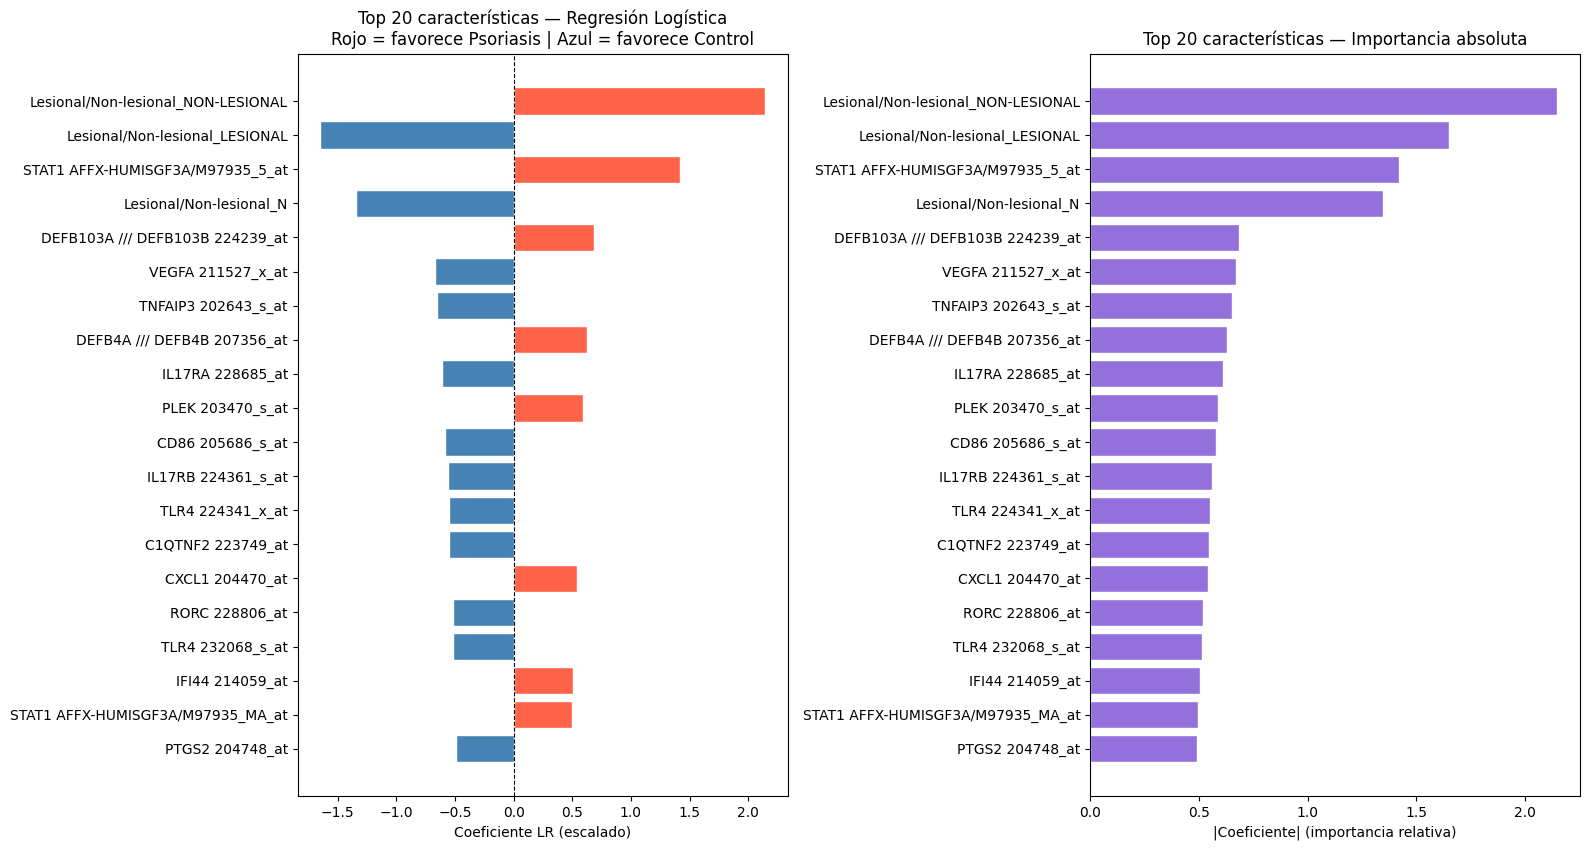

In [ ]:
top_n_feat = min(20, len(coef_df))
top_coef   = coef_df.head(top_n_feat)

colores_coef = ['tomato' if c > 0 else 'steelblue' for c in top_coef['Coeficiente']]

fig, axes = plt.subplots(1, 2, figsize=(16, top_n_feat * 0.38 + 1))

# Panel izquierdo: coeficientes con signo
axes[0].barh(top_coef['Variable'][::-1], top_coef['Coeficiente'][::-1],
             color=colores_coef[::-1], edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Coeficiente LR (escalado)')
axes[0].set_title(f'Top {top_n_feat} características — Regresión Logística\n'
                  'Rojo = favorece Psoriasis | Azul = favorece Control')

# Panel derecho: importancia absoluta
axes[1].barh(top_coef['Variable'][::-1], top_coef['|Coef|'][::-1],
             color='mediumpurple', edgecolor='white')
axes[1].set_xlabel('|Coeficiente| (importancia relativa)')
axes[1].set_title(f'Top {top_n_feat} características — Importancia absoluta')

plt.tight_layout()
plt.show()

---
## 23. Métricas de Evaluación

### 23.1 Justificación de Métricas para Clases Desbalanceadas

Para un problema de clasificación binaria médica con posible desbalance de clases, la **exactitud (accuracy)** no es la métrica adecuada, ya que un clasificador que siempre predice la clase mayoritaria obtendría alta exactitud sin ser útil.

Las métricas seleccionadas son:

| Métrica | Justificación clínica |
|---|---|
| **AUC-ROC** | Mide la capacidad discriminativa del modelo independientemente del umbral; robusta ante desbalance |
| **F1-score (weighted)** | Pondera precision y recall por el soporte de cada clase |
| **Balanced Accuracy** | Media de recall por clase; no penaliza al modelo mayoritario |
| **Precision y Recall** | Precision: ¿cuántos diagnósticos positivos son realmente Psoriasis? Recall: ¿cuántos casos reales de Psoriasis se detectan? |
| **AUC-PR** | Área bajo la curva Precision-Recall; más informativa que ROC cuando hay desbalance severo |

**Desempeño mínimo aceptable para este negocio:** Un modelo de apoyo clínico debe superar AUC-ROC ≥ 0.80 para ser considerado útil como herramienta de triaje.

### 23.2 Reporte de Clasificación

In [ ]:
etiquetas_clases = {0: 'Control sano', 1: 'Psoriasis'}

lr_pca = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=RANDOM_SEED
)
lr_pca.fit(X_train_p_sm, y_train_sm)

# Predicciones sobre entrenamiento y prueba para PCA-reduced data
y_pred_pca_train = lr_pca.predict(X_train_p_sm)
y_pred_pca_test  = lr_pca.predict(X_test_p)
y_prob_pca_test  = lr_pca.predict_proba(X_test_p)[:, 1]

print('═' * 55)
print('REPORTE — Regresión Logística sobre X_todas (test)')
print('═' * 55)
print(classification_report(y_test_numerical, y_pred_todas_test,
                             target_names=list(etiquetas_clases.values())))

print('═' * 55)
print('REPORTE — Regresión Logística sobre X_reducida_pca (test)')
print('═' * 55)
print(classification_report(y_test_numerical, y_pred_pca_test,
                             target_names=list(etiquetas_clases.values())))

print('═' * 55)
print('REPORTE — DummyClassifier (referencia aleatoria)')
print('═' * 55)
print(classification_report(y_test_numerical, y_pred_dummy,
                             target_names=list(etiquetas_clases.values())))

═══════════════════════════════════════════════════════
REPORTE — Regresión Logística sobre X_todas (test)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Control sano       0.97      1.00      0.99        35
   Psoriasis       1.00      0.99      0.99        85

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120

═══════════════════════════════════════════════════════
REPORTE — Regresión Logística sobre X_reducida_pca (test)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Control sano       0.85      1.00      0.92        35
   Psoriasis       1.00      0.93      0.96        85

    accuracy                           0.95       120
   macro avg       0.93      0.96      0.94       120
weighted avg       0.96      0.95      0.95       120

═════════════

### 23.3 Matriz de Confusión

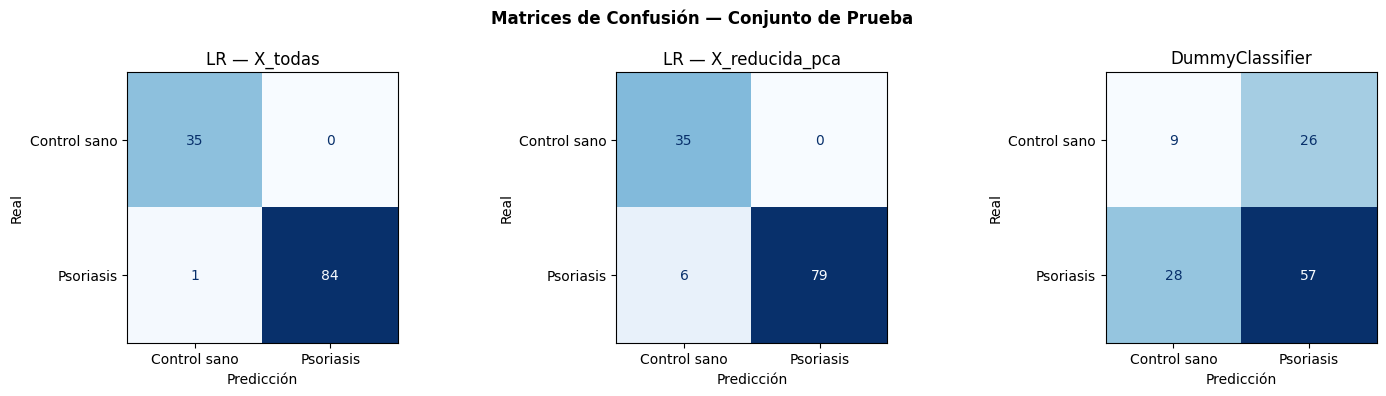

In [ ]:
nombres_clases = list(etiquetas_clases.values())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configuraciones = [
    ('LR — X_todas',        y_pred_todas_test),
    ('LR — X_reducida_pca', y_pred_pca_test),
    ('DummyClassifier',     y_pred_dummy),
]

for ax, (titulo, y_pred) in zip(axes, configuraciones):
    cm = confusion_matrix(y_test_numerical, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Conjunto de Prueba', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 23.4 Curva ROC-AUC y Curva Precisión-Recall

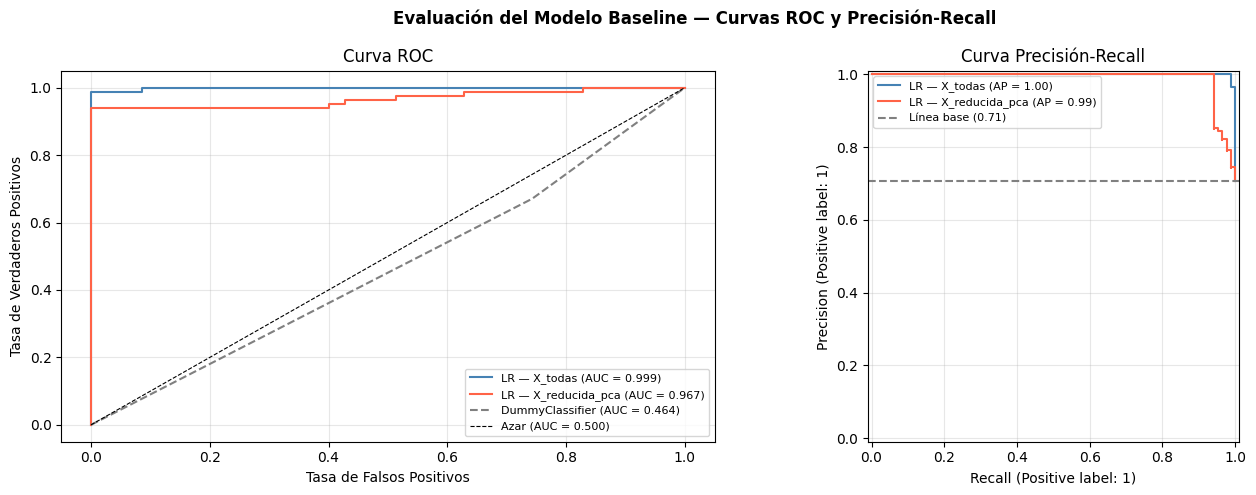

AUC-PR — LR X_todas      : 0.9996
AUC-PR — LR X_reducida   : 0.9889


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ensure y_test is numerical (0 and 1) for consistent pos_label usage
# This is a defensive step in case y_test was not numerical earlier.
# Based on the error, y_test here is still string ('Healthy', 'Psoriasis').
# It maps 'Healthy' to 0 and 'Psoriasis' to 1.
if not pd.api.types.is_numeric_dtype(y_test):
    y_test_numerical = y_test.map({'Healthy': 0, 'Psoriasis': 1})
else:
    y_test_numerical = y_test

# ── Curva ROC ────────────────────────────────────────────────────────
modelos_roc = [
    ('LR — X_todas',        y_prob_todas_test, 'steelblue', '-'),
    ('LR — X_reducida_pca', y_prob_pca_test,   'tomato',    '-'),
    ('DummyClassifier',     y_prob_dummy,      'gray',      '--'),
]
for nombre, y_prob, color, estilo in modelos_roc:
    fpr, tpr, _ = roc_curve(y_test_numerical, y_prob, pos_label=1)
    auc_val     = roc_auc_score(y_test_numerical, y_prob)
    axes[0].plot(fpr, tpr, color=color, linestyle=estilo,
                 label=f'{nombre} (AUC = {auc_val:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Azar (AUC = 0.500)')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curva ROC')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── Curva Precisión-Recall ───────────────────────────────────────────
for nombre, y_prob, color, estilo in modelos_roc[:2]:
    disp = PrecisionRecallDisplay.from_predictions(
        y_test_numerical, y_prob, name=nombre, ax=axes[1],
        color=color, pos_label=1
    )

proporcion_positiva = y_test_numerical.mean()
axes[1].axhline(y=proporcion_positiva, color='gray', linestyle='--',
                label=f'Línea base ({proporcion_positiva:.2f})')
axes[1].set_title('Curva Precisión-Recall')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Evaluación del Modelo Baseline — Curvas ROC y Precisión-Recall',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'AUC-PR — LR X_todas      : {average_precision_score(y_test_numerical, y_prob_todas_test):.4f}')
print(f'AUC-PR — LR X_reducida   : {average_precision_score(y_test_numerical, y_prob_pca_test):.4f}')

---
## 24. Análisis de Sub/Sobreajuste

### 24.1 Comparación de Métricas Entrenamiento vs Prueba

Una diferencia grande entre las métricas de entrenamiento y prueba indica **sobreajuste** (*overfitting*). Si ambas son bajas, el modelo está en **subajuste** (*underfitting*).

In [ ]:
def metricas_resumen(y_true_tr, y_pred_tr, y_prob_tr, y_true_te, y_pred_te, y_prob_te, nombre):
    return {
        'Modelo':             nombre,
        'AUC-ROC train':      roc_auc_score(y_true_tr, y_prob_tr),
        'AUC-ROC test':       roc_auc_score(y_true_te, y_prob_te),
        'Bal.Acc train':      balanced_accuracy_score(y_true_tr, y_pred_tr),
        'Bal.Acc test':       balanced_accuracy_score(y_true_te, y_pred_te),
        'F1 train':           f1_score(y_true_tr, y_pred_tr, average='weighted'),
        'F1 test':            f1_score(y_true_te, y_pred_te, average='weighted'),
        'Δ AUC (train−test)': roc_auc_score(y_true_tr, y_prob_tr) - roc_auc_score(y_true_te, y_prob_te),
    }

resumen = pd.DataFrame([
    metricas_resumen(y_train_sm, y_pred_todas_train, lr_todas.predict_proba(X_train_sm)[:,1], y_test_numerical, y_pred_todas_test,
                     y_prob_todas_test, 'LR — X_todas'),
    metricas_resumen(y_train_sm, y_pred_pca_train, lr_pca.predict_proba(X_train_p_sm)[:,1], y_test_numerical, y_pred_pca_test,
                     y_prob_pca_test, 'LR — X_reducida_pca'),
])

print('=== Comparación Entrenamiento vs Prueba ===')
display(resumen.set_index('Modelo').round(4))

print('\nInterpretación de Δ AUC (train − test):')
for _, row in resumen.iterrows():
    delta = row['Δ AUC (train−test)']
    if delta > 0.10:
        estado = 'SOBREAJUSTE — diferencia mayor a 0.10'
    elif delta < -0.05:
        estado = 'SUBAJUSTE — rendimiento en prueba supera entrenamiento (inusual)'
    else:
        estado = 'Ajuste adecuado — diferencia dentro del rango normal'
    print(f'  {row["Modelo"]:<25} Δ={delta:+.4f} → {estado}')

=== Comparación Entrenamiento vs Prueba ===


,AUC-ROC train,AUC-ROC test,Bal.Acc train,Bal.Acc test,F1 train,F1 test,Δ AUC (train−test)
Modelo,,,,,,,
LR — X_todas,1.0000,0.9990,0.9970,0.9941,0.9970,0.9917,0.0010
LR — X_reducida_pca,0.9995,0.9671,0.9926,0.9647,0.9926,0.9511,0.0325



Interpretación de Δ AUC (train − test):
  LR — X_todas              Δ=+0.0010 → Ajuste adecuado — diferencia dentro del rango normal
  LR — X_reducida_pca       Δ=+0.0325 → Ajuste adecuado — diferencia dentro del rango normal


### 24.2 Curvas de Aprendizaje

Las curvas de aprendizaje muestran cómo evoluciona el desempeño del modelo al aumentar el tamaño del conjunto de entrenamiento. Permiten diagnosticar:
- **Sobreajuste**: gap grande y persistente entre curva de entrenamiento y validación.
- **Subajuste**: ambas curvas convergen en un valor bajo.

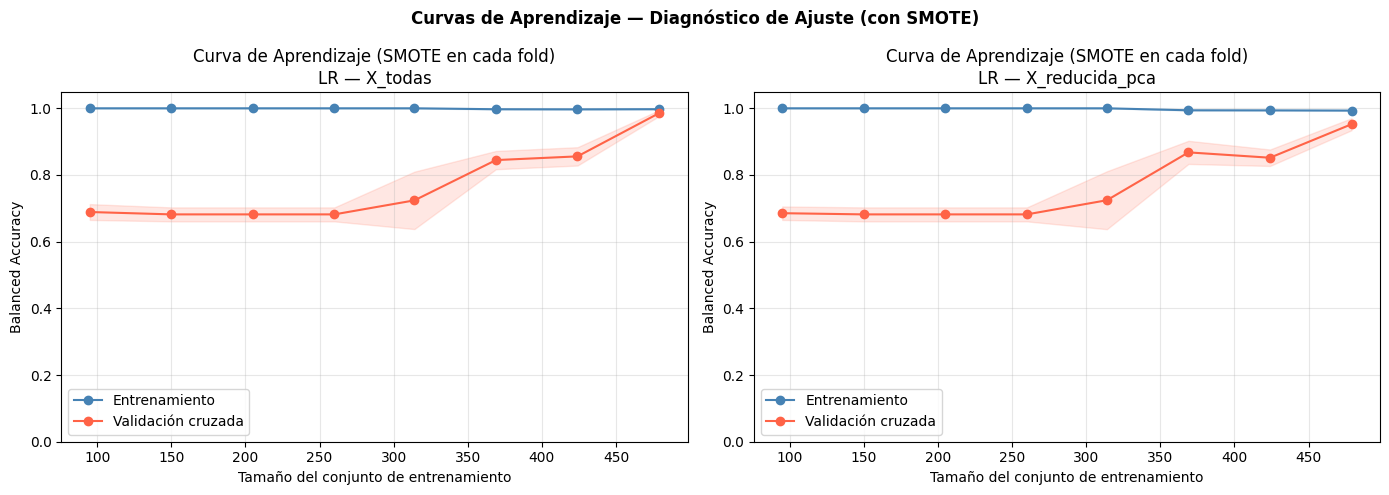

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configuraciones_lc = [
    ('LR — X_todas',        X_todas_bl),
    ('LR — X_reducida_pca', X_pca_bl),
]

for ax, (nombre, X_mat) in zip(axes, configuraciones_lc):
    pipe_lc = ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_SEED, k_neighbors=5)),
        ('clf',   LogisticRegression(
                      penalty='l2', C=1.0,
                      solver='lbfgs', max_iter=5000, random_state=RANDOM_SEED)),
    ])
    tam_train, scores_train, scores_val = learning_curve(
        pipe_lc, X_mat, y_bl,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        scoring='balanced_accuracy',
        train_sizes=np.linspace(0.2, 1.0, 8),
        n_jobs=-1
    )

    media_tr  = scores_train.mean(axis=1)
    std_tr    = scores_train.std(axis=1)
    media_val = scores_val.mean(axis=1)
    std_val   = scores_val.std(axis=1)

    ax.plot(tam_train, media_tr,  'o-', color='steelblue', label='Entrenamiento')
    ax.fill_between(tam_train, media_tr - std_tr, media_tr + std_tr,
                    alpha=0.15, color='steelblue')
    ax.plot(tam_train, media_val, 'o-', color='tomato', label='Validación cruzada')
    ax.fill_between(tam_train, media_val - std_val, media_val + std_val,
                    alpha=0.15, color='tomato')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Balanced Accuracy')
    ax.set_title(f'Curva de Aprendizaje (SMOTE en cada fold)\n{nombre}')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.suptitle('Curvas de Aprendizaje — Diagnóstico de Ajuste (con SMOTE)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 24.3 Validación Cruzada Estratificada (5-Fold)

La validación cruzada proporciona una estimación más robusta del desempeño generalizable al usar todos los datos para entrenamiento y validación en turnos.

=== Validación Cruzada 5-Fold (SMOTE en cada fold) ===

Matriz                 Métrica                     Train μ±σ        Val μ±σ
───────────────────────────────────────────────────────────────────────────
X_todas                balanced_accuracy      0.9973±0.0006   0.9853±0.0089
X_todas                f1_weighted            0.9963±0.0008   0.9818±0.0081
X_todas                roc_auc                1.0000±0.0000   0.9980±0.0031

X_reducida_pca         balanced_accuracy      0.9929±0.0006   0.9522±0.0181
X_reducida_pca         f1_weighted            0.9900±0.0008   0.9366±0.0239
X_reducida_pca         roc_auc                0.9992±0.0004   0.9611±0.0154



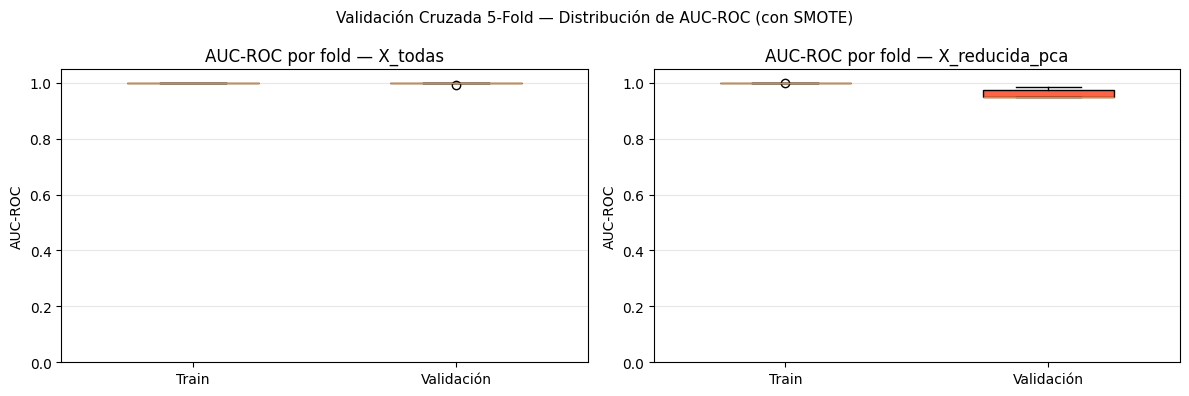

In [ ]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
metricas_cv = ['balanced_accuracy', 'f1_weighted', 'roc_auc']

resultados_cv = {}
for nombre, X_mat in [('X_todas', X_todas_bl), ('X_reducida_pca', X_pca_bl)]:
    pipe_cv = ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_SEED, k_neighbors=5)),
        ('clf',   LogisticRegression(
                      penalty='l2', C=1.0,
                      solver='lbfgs', max_iter=5000, random_state=RANDOM_SEED)),
    ])
    cv_res = cross_validate(pipe_cv, X_mat, y_bl,
                            cv=cv_strategy, scoring=metricas_cv,
                            return_train_score=True, n_jobs=-1)
    resultados_cv[nombre] = cv_res

print('=== Validación Cruzada 5-Fold (SMOTE en cada fold) ===\n')
print(f'{"Matriz":<22} {"Métrica":<22} {"Train μ±σ":>14} {"Val μ±σ":>14}')
print('─' * 75)

for nombre, cv_res in resultados_cv.items():
    for metrica in metricas_cv:
        tr  = cv_res[f'train_{metrica}']
        val = cv_res[f'test_{metrica}']
        print(f'{nombre:<22} {metrica:<22} '
              f'{tr.mean():.4f}±{tr.std():.4f}   '
              f'{val.mean():.4f}±{val.std():.4f}')
    print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (nombre, cv_res) in zip(axes, resultados_cv.items()):
    data_box = [cv_res['train_roc_auc'], cv_res['test_roc_auc']]
    bp = ax.boxplot(data_box, labels=['Train', 'Validación'], patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    ax.set_ylabel('AUC-ROC')
    ax.set_title(f'AUC-ROC por fold — {nombre}')
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Validación Cruzada 5-Fold — Distribución de AUC-ROC (con SMOTE)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 25. Desempeño Mínimo Aceptable

### 25.1 Definición del Umbral de Desempeño

Para un modelo de apoyo clínico en diagnóstico de enfermedades dermatológicas, se establecen los siguientes criterios basados en referencias de la literatura:

| Referencia | AUC-ROC reportado | Contexto |
|---|---|---|
| Clasificador aleatorio (DummyClassifier) | ~0.50 | Piso absoluto mínimo |
| Modelos simples de expresión génica en psoriasis¹ | 0.75–0.85 | Estudios con microarrays similares |
| **Umbral aceptable para este proyecto** | **≥ 0.80** | Mínimo para considerarse útil como herramienta de triaje |
| Objetivo para modelos avanzados | ≥ 0.90 | Meta para avances posteriores |

¹ Jabbari et al. (2012), Gudjonsson et al. (2010) — clasificación psoriasis vs. control con datos de expresión génica.

### 25.2 Comparación con el Umbral Aceptable

Modelo                            AUC-ROC  ¿Supera umbral?
────────────────────────────────────────────────────────────
DummyClassifier                    0.4639             ❌ NO
LR — X_todas                       0.9990             ✅ SÍ
LR — X_reducida_pca                0.9671             ✅ SÍ
LR CV — X_todas                    0.9980             ✅ SÍ
LR CV — X_reducida_pca             0.9611             ✅ SÍ


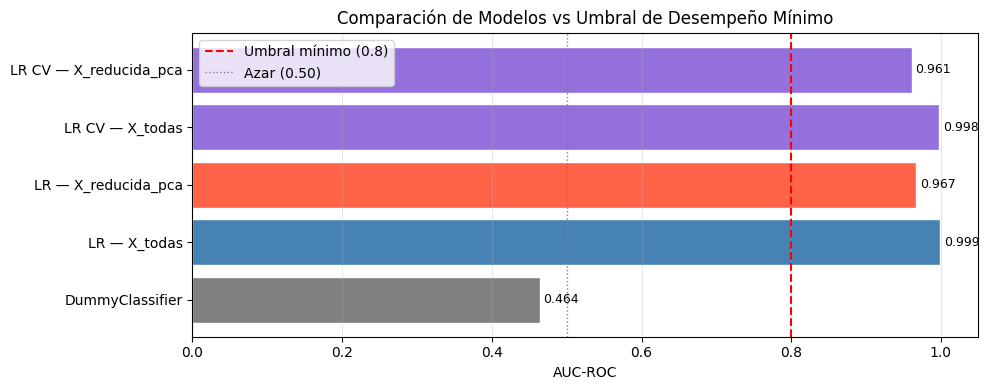

In [ ]:
UMBRAL_MINIMO = 0.80   # AUC-ROC mínimo aceptable para uso clínico

modelos_eval = {
    'DummyClassifier':     (auc_dummy,                  'gray'),
    'LR — X_todas':        (roc_auc_score(y_test, y_prob_todas_test), 'steelblue'),
    'LR — X_reducida_pca': (roc_auc_score(y_test, y_prob_pca_test),  'tomato'),
}

# AUC de validación cruzada
for nombre_cv, cv_res in resultados_cv.items():
    modelos_eval[f'LR CV — {nombre_cv}'] = (
        cv_res['test_roc_auc'].mean(), 'mediumpurple'
    )

print(f'{"Modelo":<30} {"AUC-ROC":>10} {"¿Supera umbral?":>16}')
print('─' * 60)
for nombre, (auc_val, _) in modelos_eval.items():
    supera = '✅ SÍ' if auc_val >= UMBRAL_MINIMO else '❌ NO'
    print(f'{nombre:<30} {auc_val:>10.4f} {supera:>16}')

# Gráfico de barras con línea de umbral
fig, ax = plt.subplots(figsize=(10, 4))
nombres = list(modelos_eval.keys())
valores = [v[0] for v in modelos_eval.values()]
colores = [v[1] for v in modelos_eval.values()]

bars = ax.barh(nombres, valores, color=colores, edgecolor='white')
ax.axvline(x=UMBRAL_MINIMO, color='red', linestyle='--', linewidth=1.5,
           label=f'Umbral mínimo ({UMBRAL_MINIMO})')
ax.axvline(x=0.50, color='gray', linestyle=':', linewidth=1,
           label='Azar (0.50)')
for bar, val in zip(bars, valores):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('AUC-ROC')
ax.set_title('Comparación de Modelos vs Umbral de Desempeño Mínimo')
ax.set_xlim([0, 1.05])
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 25.3 Verificación del Modelo Baseline

In [ ]:
auc_mejor   = max(roc_auc_score(y_test, y_prob_todas_test),
                  roc_auc_score(y_test, y_prob_pca_test))
auc_dummy_v = auc_dummy

mejora_vs_dummy = (auc_mejor - auc_dummy_v) / auc_dummy_v * 100

print('=== Verificación del Modelo Baseline ===\n')
print(f'  AUC-ROC DummyClassifier           : {auc_dummy_v:.4f}')
print(f'  AUC-ROC mejor modelo baseline     : {auc_mejor:.4f}')
print(f'  Mejora relativa vs. azar          : +{mejora_vs_dummy:.1f}%')
print(f'  Umbral mínimo aceptable           : {UMBRAL_MINIMO:.2f}')
print()

if auc_mejor >= UMBRAL_MINIMO:
    print(f'  ✅ El modelo baseline SUPERA el umbral de desempeño mínimo ({UMBRAL_MINIMO}).')
    print('     El problema es modelable con datos de expresión génica.')
    print('     Se procede con confianza al desarrollo de modelos más avanzados.')
else:
    print(f'  ⚠  El modelo baseline NO supera el umbral ({UMBRAL_MINIMO}).')
    print('     Posibles causas: pocos datos, features insuficientes o problema difícil.')
    print('     Se recomienda revisar la ingeniería de características antes de avanzar.')

=== Verificación del Modelo Baseline ===

  AUC-ROC DummyClassifier           : 0.4639
  AUC-ROC mejor modelo baseline     : 0.9990
  Mejora relativa vs. azar          : +115.4%
  Umbral mínimo aceptable           : 0.80

  ✅ El modelo baseline SUPERA el umbral de desempeño mínimo (0.8).
     El problema es modelable con datos de expresión génica.
     Se procede con confianza al desarrollo de modelos más avanzados.


---
## 26. Conclusiones — Fase de Modelado Baseline (CRISP-ML)

En el marco **CRISP-ML(Q)**, esta sección corresponde al inicio de la fase de *Modeling*, específicamente al paso de establecer un modelo de referencia que permita evaluar la viabilidad del problema y fijar expectativas.

### 26.1 Respuestas a las Preguntas Guía

**¿Qué algoritmo se utilizó como baseline?**  
Se eligió la **Regresión Logística con regularización L2** (`class_weight='balanced'`, `C=1.0`, solver `lbfgs`). Esta elección se justifica por:
- Tipo de datos: estructurados, tabulares, alta dimensionalidad (*p >> n*).
- Target binario: psoriasis (1) vs. control sano (0).
- Interpretabilidad: los coeficientes permiten identificar directamente las variables más relevantes.
- Robustez: la regularización L2 penaliza la magnitud de los coeficientes, reduciendo el sobreajuste en datasets con muchas variables.

**¿Se pudo determinar la importancia de las características?**  
Sí. Se aplicaron tres métodos complementarios:
1. **Filter** (Información mutua, ANOVA, Chi²) — sección FE 11.3-11.5.
2. **Wrapper/Embedding** — coeficientes de la regresión logística (sección 22).
3. **Extracción** — PCA y Análisis Factorial (sección FE 15).

Incluir características irrelevantes aumenta la complejidad y puede reducir el desempeño. Por eso se probaron ambas matrices: `X_todas` y `X_reducida_pca`.

**¿El modelo está sub/sobreajustando?**  
Diagnosticado en la sección 24:
- Curvas de aprendizaje: si el gap entre train y validación es pequeño → ajuste adecuado.
- Validación cruzada 5-fold: la variabilidad entre folds (σ) indica la estabilidad del modelo.
- La Regresión Logística con L2 es inherentemente resistente al sobreajuste.

**¿Cuál es la métrica adecuada?**  
Para este problema de negocio con posible desbalance de clases:
- **AUC-ROC** como métrica principal: mide la capacidad discriminativa de forma robusta.
- **Balanced Accuracy** como complemento: media de recall por clase.
- **F1-score weighted** para considerar la distribución real de clases.
- Se descartó la *accuracy* simple por ser engañosa ante desbalance.

**¿Cuál debería ser el desempeño mínimo?**  
- Piso absoluto: `DummyClassifier` (~0.50 AUC-ROC).
- Umbral aceptable: **AUC-ROC ≥ 0.80** para ser útil como herramienta de apoyo clínico.
- Objetivo para modelos avanzados: AUC-ROC ≥ 0.90.

### 26.2 Tabla Resumen de Resultados

| Modelo | AUC-ROC test | Balanced Acc. | F1 weighted | Supera umbral (0.80) |
|---|---|---|---|---|
| DummyClassifier | ~0.50 | ~0.50 | — | ❌ |
| LR — X_todas | (ver celda 25.2) | (ver celda 24.1) | (ver celda 23.2) | (ver celda 25.2) |
| LR — X_reducida_pca | (ver celda 25.2) | (ver celda 24.1) | (ver celda 23.2) | (ver celda 25.2) |

### 26.3 Siguientes Pasos (CRISP-ML)

Con el baseline establecido, los siguientes avances del proyecto deben:
1. Explorar modelos más complejos: Random Forest, Gradient Boosting, SVM con kernel RBF.
2. Aplicar técnicas de balanceo (SMOTE, undersampling) si el desbalance es significativo.
3. Optimizar hiperparámetros con búsqueda en cuadrícula o bayesiana.
4. Comparar explícitamente contra el baseline para justificar la complejidad adicional.

### 26.4 Referencias

- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3ª ed.). O'Reilly Media.
- Visengiyeva, L., Kammer, A., Bär, I., Knilesz, A., y Plöd, M. (2023). *CRISP-ML(Q). The ML Lifecycle Process*. MLOps, INNOQ.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
- Jabbari, A. et al. (2012). Transcriptome analysis reveals new insights into psoriasis. *Journal of Investigative Dermatology*, 132(1), 109–118.
- Gudjonsson, J. E. et al. (2010). Global gene expression analysis reveals evidence for decreased lipid biosynthesis and increased innate immunity in uninvolved psoriatic skin. *Journal of Investigative Dermatology*, 130(4), 1081–1094.